hard vs soft voting comparison
----------------------------------------
logistic regression -> 0.981
random forest -> 0.956
svm -> 0.974
hard voting -> 0.981
soft voting -> 0.979


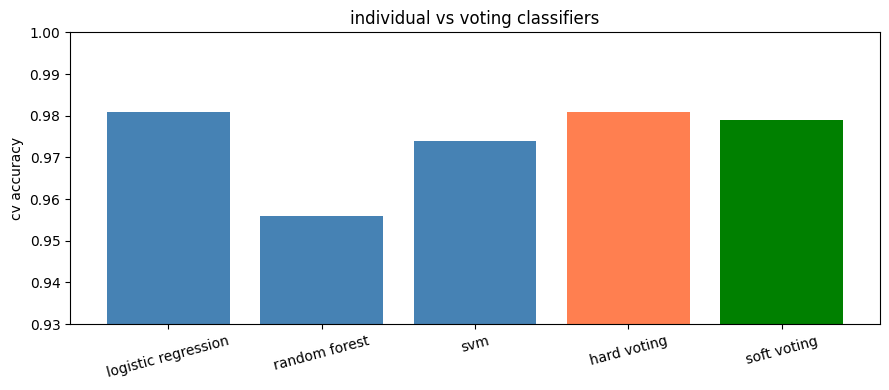

In [2]:
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

cancer = load_breast_cancer()
x = cancer.data
y = cancer.target

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_train, x_test, y_train, y_test = train_test_split(
    x_scaled, y, test_size=0.2, random_state=42
)

lr = LogisticRegression(max_iter=1000, random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42)
svc_soft = SVC(probability=True, random_state=42)

hard_voting = VotingClassifier(
    estimators=[("lr", lr), ("rf", rf), ("svc", svc_soft)],
    voting="hard"
)

soft_voting = VotingClassifier(
    estimators=[("lr", lr), ("rf", rf), ("svc", svc_soft)],
    voting="soft"
)

models = {
    "logistic regression": lr,
    "random forest":       rf,
    "svm":                 svc_soft,
    "hard voting":         hard_voting,
    "soft voting":         soft_voting
}

print("hard vs soft voting comparison")
print("-" * 40)

scores = {}
for name, model in models.items():
    cv = cross_val_score(model, x_scaled, y, cv=5)
    scores[name] = round(np.mean(cv), 3)
    print(name, "->", scores[name])

plt.figure(figsize=(9, 4))
colors = ["steelblue", "steelblue", "steelblue", "coral", "green"]
plt.bar(scores.keys(), scores.values(), color=colors)
plt.title("individual vs voting classifiers")
plt.ylabel("cv accuracy")
plt.ylim(0.93, 1.0)
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()